In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
ds = pd.read_csv('Housing.csv')
ds.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
col = ds.columns
col

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
ds = pd.get_dummies(ds, drop_first=True)
ds

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [9]:
X = ds[['area', 'bedrooms']]
y = ds['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model 1 (2 Features)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Model 1 (2 Features)
R2 Score: 0.4366388245845252
MAE: 1012961.5894373473
MSE: 1915916213713.8357


In [10]:
X = ds[['area','bedrooms','bathrooms','stories','parking']]
y = ds['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel 2 (5 Features)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Model 2 (5 Features)
R2 Score: 0.6453433328353939
MAE: 814356.5091382216
MSE: 1206140019182.6484


In [11]:
X = ds.drop('price', axis=1)
y = ds['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel 3 (All Features)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Model 3 (All Features)
R2 Score: 0.7560355994624843
MAE: 736886.1661127881
MSE: 829690385060.8577


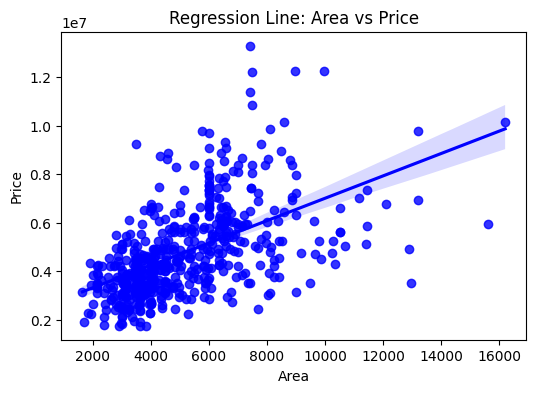

In [14]:
plt.figure(figsize=(6,4))
sns.regplot(x="area", y="price", data=ds, color="blue")

plt.title("Regression Line: Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

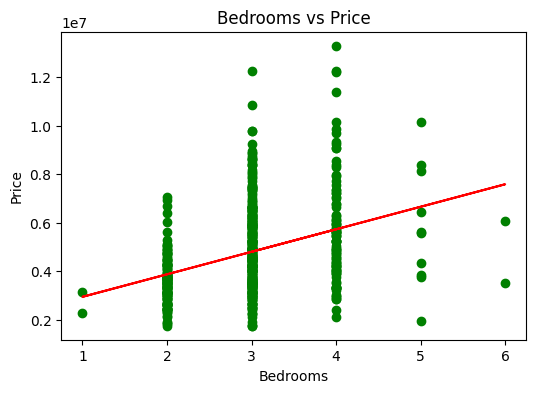

In [15]:
X = ds[['bedrooms']]
y = ds['price']

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(6,4))
plt.scatter(ds['bedrooms'], ds['price'], color='green')
plt.plot(ds['bedrooms'], model.predict(X), color='red')

plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

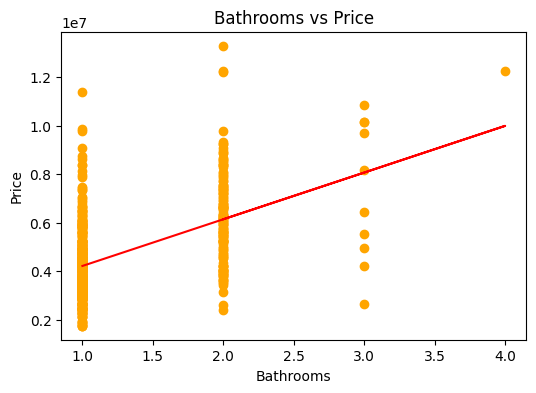

In [16]:
X = ds[['bathrooms']]
y = ds['price']

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(6,4))
plt.scatter(ds['bathrooms'], ds['price'], color='orange')
plt.plot(ds['bathrooms'], model.predict(X), color='red')

plt.title("Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")

plt.show()